In [7]:
import torch
import numpy as np
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data.sampler import SubsetRandomSampler
import torch.nn as nn
from datetime import datetime
import matplotlib.pyplot as plt

# Device selection for Apple Silicon (MPS) or fallback CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")


Using MPS (Apple GPU)


In [8]:
transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Imagenet mean
                         std=[0.229, 0.224, 0.225])   # Imagenet std
])

dataset = datasets.ImageFolder("/Users/felixkevinsinght/TN/PlantDiseasesDataset", transform=transform)
print(f"Total dataset size: {len(dataset)}")
print(f"Classes: {dataset.classes}")


Total dataset size: 125024
Classes: ['Apple', 'Bell pepper', 'Cherry', 'Citrus', 'Corn', 'Grape', 'Peach', 'Potato', 'Strawberry', 'Tomato']


In [9]:
indices = list(range(len(dataset)))
np.random.seed(42)  # reproducible
np.random.shuffle(indices)

train_split = 0.7
val_split = 0.15  # total train + val = 0.85
test_split = 0.15

train_end = int(train_split * len(dataset))
val_end = train_end + int(val_split * len(dataset))

train_indices = indices[:train_end]
val_indices = indices[train_end:val_end]
test_indices = indices[val_end:]

print(f"Train size: {len(train_indices)}")
print(f"Validation size: {len(val_indices)}")
print(f"Test size: {len(test_indices)}")

train_sampler = SubsetRandomSampler(train_indices)
val_sampler = SubsetRandomSampler(val_indices)
test_sampler = SubsetRandomSampler(test_indices)


Train size: 87516
Validation size: 18753
Test size: 18755


In [10]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
val_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=val_sampler)
test_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=test_sampler)


In [11]:
class CNN(nn.Module):
    def __init__(self, K):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
        )
        self.dense_layers = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(50176, 1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, K),
        )
    def forward(self, X):
        out = self.conv_layers(X)
        out = out.view(-1, 50176)
        out = self.dense_layers(out)
        return out

targets_size = len(dataset.classes)
model = CNN(targets_size).to(device)
print(model)


CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)


In [14]:
def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, epochs=20):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_wts = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * inputs.size(0)

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        scheduler.step(epoch_val_loss)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} Val Loss: {epoch_val_loss:.4f}")

        # Save best model weights
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = model.state_dict()

    # Load best model weights
    if best_model_wts:
        model.load_state_dict(best_model_wts)

    return train_losses, val_losses


In [15]:
train_losses, val_losses = train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, epochs=20)


Epoch 1/20 - Train Loss: 0.7175 Val Loss: 0.0668
Epoch 2/20 - Train Loss: 0.3180 Val Loss: 0.0380
Epoch 3/20 - Train Loss: 0.2107 Val Loss: 0.0318
Epoch 4/20 - Train Loss: 0.1697 Val Loss: 0.0271
Epoch 5/20 - Train Loss: 0.1392 Val Loss: 0.0245
Epoch 6/20 - Train Loss: 0.1195 Val Loss: 0.0181
Epoch 7/20 - Train Loss: 0.0999 Val Loss: 0.0221
Epoch 8/20 - Train Loss: 0.0885 Val Loss: 0.0165
Epoch 9/20 - Train Loss: 0.0807 Val Loss: 0.0125
Epoch 10/20 - Train Loss: 0.0747 Val Loss: 0.0127
Epoch 11/20 - Train Loss: 0.0668 Val Loss: 0.0130
Epoch 12/20 - Train Loss: 0.0621 Val Loss: 0.0151
Epoch 13/20 - Train Loss: 0.0577 Val Loss: 0.0138
Epoch 14/20 - Train Loss: 0.0319 Val Loss: 0.0091
Epoch 15/20 - Train Loss: 0.0278 Val Loss: 0.0098
Epoch 16/20 - Train Loss: 0.0299 Val Loss: 0.0088
Epoch 17/20 - Train Loss: 0.0260 Val Loss: 0.0100
Epoch 18/20 - Train Loss: 0.0255 Val Loss: 0.0093
Epoch 19/20 - Train Loss: 0.0268 Val Loss: 0.0084
Epoch 20/20 - Train Loss: 0.0228 Val Loss: 0.0103


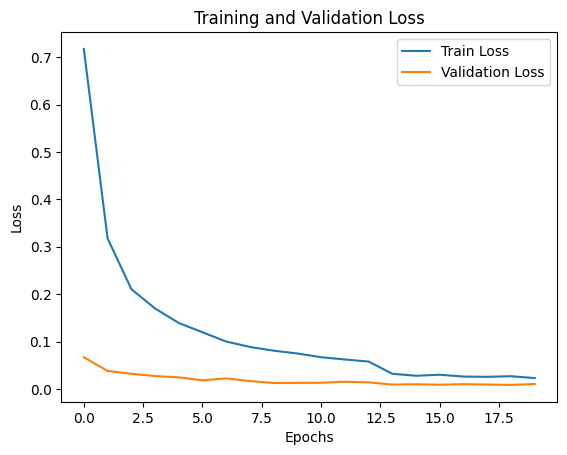

In [18]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


In [19]:
def accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

train_acc = accuracy(train_loader)
val_acc = accuracy(val_loader)
test_acc = accuracy(test_loader)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Train Accuracy: 0.9964
Validation Accuracy: 0.9858
Test Accuracy: 0.9854


In [1]:
# Save the trained model weights
torch.save(model.state_dict(), "plant_disease_model_12.p")
print("Model saved as plant_disease_model_12.p")


NameError: name 'torch' is not defined

In [32]:
# Define the same model architecture
targets_size = len(dataset.classes)  # or your known number of classes, e.g., 39

model = CNN(39)

# Set device as per your new device detection logic
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

model.load_state_dict(torch.load("plant_disease_model_12.p", map_location=device))
model.to(device)
model.eval()  # Set model to evaluation mode
print("Model loaded and ready for prediction")


Using MPS (Apple GPU)
Model loaded and ready for prediction


In [33]:
from PIL import Image
import torchvision.transforms.functional as TF
import numpy as np

# Reverse index mapping to get class names from index
index_to_disease = {v: k for k, v in dataset.class_to_idx.items()}

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))
    
    input_tensor = TF.to_tensor(image).unsqueeze(0).to(device)  # Shape: (1, 3, 224, 224)
    
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted_index = torch.max(probabilities, 1)
    
    predicted_class = index_to_disease[predicted_index.item()]
    confidence_score = confidence.item()
    
    print(f"Prediction: {predicted_class} (Confidence: {confidence_score:.4f})")
    return predicted_class, confidence_score


In [34]:
image_path = "/Users/felixkevinsinght/TN/PlantDiseasesDataset/Cherry/train/Cherry Powdery mildew/CherryPowderyMildew(6).JPG"
predict_image(image_path)


KeyError: 38